# Network Generator
This is a notebook to help creating new networks by visualizing them. Use the `run all` button

In [98]:
import random
import os
os.chdir('/Users/synneandreassen/Documents/MasterMaskinlæringCode/INF399/Environments/cyberwheel')
from cyberwheel.network.network_generation.network_generator import NetworkYAMLGenerator
from cyberwheel.network.network_base import Network
from importlib.resources import files
print(os.getcwd())

/Users/synneandreassen/Documents/MasterMaskinlæringCode/INF399/Environments/cyberwheel


In [99]:
name = "6-host-network"
num_subnets = 2
num_hosts_per_subnet = 2
network = NetworkYAMLGenerator(network_name=name)

## Add router

In [90]:
network.router("core_router")

## Add Subnets

In [91]:
for i in range(num_subnets):
    network.subnet(f"subnet{i}", "core_router", ip_range="192.168.0.0/24")
# network.subnet(f"server_subnet0", "core_router", ip_range="192.168.0.0/24")
# network.subnet(f"server_subnet1", "core_router", ip_range="192.168.0.0/24")

## Add Hosts to Subnets

First, specify some host types to randomly pick from. Seed the RNG to get the same network each time.

In [101]:
server_types = ["mail_server", "file_server", "web_server", "ssh_jump_server", "proxy_server"]
all_types = ["mail_server", "file_server", "web_server", "ssh_jump_server", "proxy_server", "workstation", "workstation", "workstation", "workstation", "workstation"]
# random.seed(10)

Use for loops to create multiple hosts on a subnet at one time

In [93]:
subnet = 0
for i in range(num_hosts_per_subnet*num_subnets):
    if i != 0 and not i % num_hosts_per_subnet:
        subnet += 1
        network.interface(f"host{i}", f"host{i-1}")
        network.interface(f"host{i-1}", f"host{i}")
    network.host(f"host{i}", f"subnet{subnet}", "workstation")

### Add some servers

In [94]:
# for i in range(1):
network.host(f"server{0}", "subnet0", random.choice(server_types))
network.host(f"server{1}", "subnet1", random.choice(server_types))
network.interface("server0", "host0")
network.interface("host0", "server0")
network.interface("server1", "host3")
network.interface("host3", "server1")
# network.interface("server3", f"host{num_hosts_per_subnet*num_subnets-1}")
# network.interface(f"host{num_hosts_per_subnet*num_subnets-1}", "server3")

## Create the YAML file in the CWD

In [100]:
config_path = files("cyberwheel.data.configs").joinpath("network")
network.output_yaml(config_path)

TypeError: 'NoneType' object is not iterable

## Visualize the New Network

In [102]:
cyberwheel_network=Network.create_network_from_yaml(config_path.joinpath(f"{name}.yaml"))


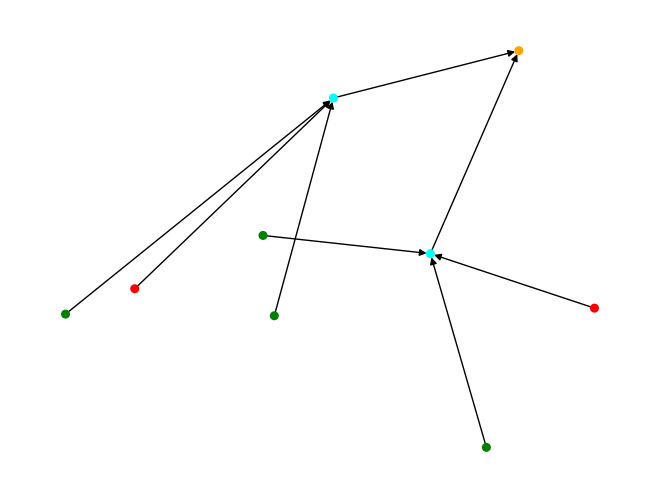

In [103]:
cyberwheel_network.draw(filename="")